<a href="https://colab.research.google.com/github/comparativechrono/Comparative-birthograms-reveal-country-specific-rephasing-of-human-birth-seasonality/blob/main/Summary_stats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

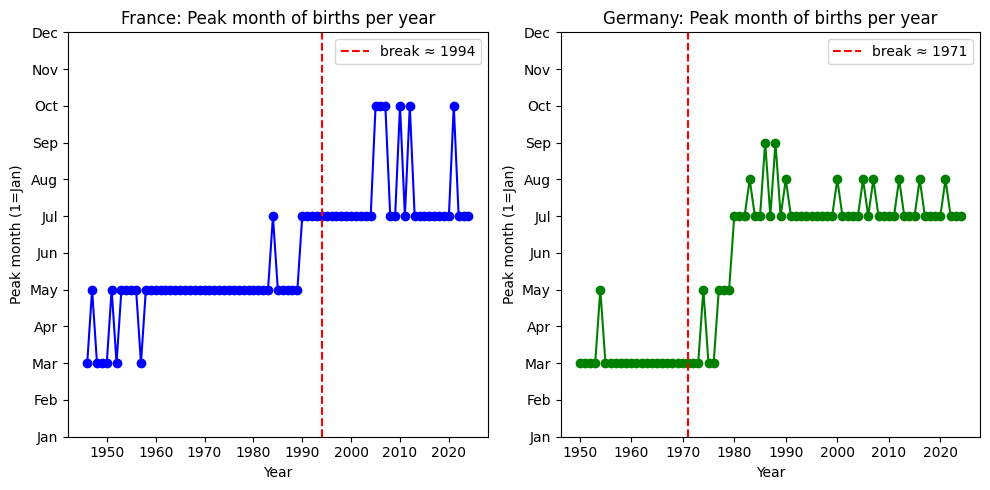

France – mean peak month pre-break: 4.96, post-break: 7.58
France – pre-break peak months: Births
5    37
3     6
7     5
Name: count, dtype: int64
France – post-break peak months: Births
7     25
10     6
Name: count, dtype: int64
Germany – mean peak month pre-break: 3.10, post-break: 6.70
Germany – pre-break peak months: Births
3    20
5     1
Name: count, dtype: int64
Germany – post-break peak months: Births
7    35
8     8
3     5
5     4
9     2
Name: count, dtype: int64


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

MONTH_MAP = {
    "January":1, "February":2, "March":3, "April":4,
    "May":5, "June":6, "July":7, "August":8,
    "September":9, "October":10, "November":11, "December":12
}
MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

def compute_peak_months(csv_file):
    df = pd.read_csv(csv_file, header=None, names=['Year','Month','Births','Photoperiod'])
    df['Month_num'] = df['Month'].map(MONTH_MAP)
    df['Date'] = pd.to_datetime(df['Year'].astype(int).astype(str) + '-' +
                                df['Month_num'].astype(int).astype(str).str.zfill(2) + '-01')
    df = df.sort_values('Date').set_index('Date')
    df['Year_num'] = df.index.year
    # For each year, find month number with max births
    peak_month_series = df.groupby('Year_num')['Births'].agg(lambda x: df.loc[x.idxmax(),'Month_num'])
    return peak_month_series

french_peak = compute_peak_months('french_photoperiod_data.csv')
german_peak = compute_peak_months('german_photoperiod_data.csv')

# Approximate break years based on previous analyses
fr_break = 1994
gm_break = 1971

# Plot
plt.figure(figsize=(10,5))
# France
plt.subplot(1,2,1)
plt.plot(french_peak.index, french_peak.values, marker='o', linestyle='-', color='blue')
plt.axvline(fr_break, color='red', linestyle='--', label=f'break ≈ {fr_break}')
plt.title('France: Peak month of births per year')
plt.xlabel('Year')
plt.ylabel('Peak month (1=Jan)')
plt.ylim(1,12)
plt.yticks(range(1,13), MONTH_LABELS)
plt.legend()
# Germany
plt.subplot(1,2,2)
plt.plot(german_peak.index, german_peak.values, marker='o', linestyle='-', color='green')
plt.axvline(gm_break, color='red', linestyle='--', label=f'break ≈ {gm_break}')
plt.title('Germany: Peak month of births per year')
plt.xlabel('Year')
plt.ylabel('Peak month (1=Jan)')
plt.ylim(1,12)
plt.yticks(range(1,13), MONTH_LABELS)
plt.legend()

plt.tight_layout()
plt.show()

# Summary statistics
fr_pre = french_peak[french_peak.index < fr_break]
fr_post= french_peak[french_peak.index >= fr_break]
print(f'France – mean peak month pre-break: {fr_pre.mean():.2f}, post-break: {fr_post.mean():.2f}')
print('France – pre-break peak months:', fr_pre.value_counts())
print('France – post-break peak months:', fr_post.value_counts())

gm_pre = german_peak[german_peak.index < gm_break]
gm_post= german_peak[german_peak.index >= gm_break]
print(f'Germany – mean peak month pre-break: {gm_pre.mean():.2f}, post-break: {gm_post.mean():.2f}')
print('Germany – pre-break peak months:', gm_pre.value_counts())
print('Germany – post-break peak months:', gm_post.value_counts())